In [1]:
# ============================================
# IMPORTS + SETUP
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("TF Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-04-19 17:31:33.153761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776619893.600141      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776619893.734487      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776619894.771038      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776619894.771090      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776619894.771094      55 computation_placer.cc:177] computation placer alr

TF Version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ============================================
# CONFIG
# ============================================

IMG_SIZE      = 192
BATCH_SIZE    = 16     # safer
EPOCHS_FROZEN = 8
EPOCHS_FINE   = 5
FINE_LAYERS   = 30
L2_REG        = 1e-4
DROPOUT       = 0.5
LABEL_SMOOTH  = 0.1
LR_FROZEN     = 1e-3
LR_FINE       = 1e-5
VAL_SPLIT     = 0.2

MODELS_TO_TRY = ["efficientnet", "mobilenet"]

In [3]:
# ============================================
# DATA PATHS
# ============================================

train_dir = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train"
test_dir  = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/test"

In [4]:
# ============================================
# DATA PIPELINE
# ============================================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    validation_split=VAL_SPLIT
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_gen = val_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

# 🔥 VALIDATION CHECK
assert len(train_gen.class_indices) == 2, "❌ Must be binary classification dataset"

class_names = list(train_gen.class_indices.keys())
idx_to_class = {v:k for k,v in train_gen.class_indices.items()}

print("Classes:", class_names)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.
Classes: ['chihuahua', 'muffin']


In [5]:
# ============================================
# MODEL FACTORY
# ============================================

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0

def get_base(name):
    try:
        if name == "mobilenet":
            return MobileNetV2(weights='imagenet', include_top=False,
                               input_shape=(IMG_SIZE, IMG_SIZE, 3))
        else:
            return EfficientNetB0(weights='imagenet', include_top=False,
                                 input_shape=(IMG_SIZE, IMG_SIZE, 3))
    except:
        print("⚠️ No internet → random weights")
        if name == "mobilenet":
            return MobileNetV2(weights=None, include_top=False,
                               input_shape=(IMG_SIZE, IMG_SIZE, 3))
        else:
            return EfficientNetB0(weights=None, include_top=False,
                                 input_shape=(IMG_SIZE, IMG_SIZE, 3))

def build_model(name):

    base = get_base(name)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(DROPOUT)(x)

    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(L2_REG))(x)
    x = layers.Dropout(DROPOUT)(x)

    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR_FROZEN),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTH),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

In [6]:
# ============================================
# TRAINING HELPERS
# ============================================

def get_callbacks(name):
    return [
        EarlyStopping(monitor='val_auc', patience=3, mode='max', restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.3),
        ModelCheckpoint(f"best_{name}.keras", monitor='val_auc', save_best_only=True, mode='max')
    ]

def train_model(model, name):

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_FROZEN,
        callbacks=get_callbacks(name),
        verbose=1
    )

    best_auc = max(history.history['val_auc'])
    return model, history, best_auc

In [7]:
# ============================================
# AUTO MODEL SELECTION
# ============================================

best_model = None
best_history = None
best_auc = 0
best_name = ""

for name in MODELS_TO_TRY:
    print(f"\n🚀 Training {name}")

    model = build_model(name)
    trained_model, history, auc_score = train_model(model, name)

    if auc_score > best_auc:
        best_auc = auc_score
        best_model = trained_model
        best_history = history
        best_name = name

print(f"\n🏆 Best Model: {best_name} (AUC={best_auc:.4f})")


🚀 Training efficientnet


I0000 00:00:1776619936.411649      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776619936.418161      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8


...

 93/237 ━━━━━━━━━━━━━━━━━━━━ 30s 211ms/step - accuracy: 0.8615 - auc: 0.9232 - loss: 0.5529

2026-04-19 17:42:23.813511: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 17:42:23.950622: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


237/237 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.8980 - auc: 0.9525 - loss: 0.4913

2026-04-19 17:43:16.544880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-19 17:43:16.678699: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


237/237 ━━━━━━━━━━━━━━━━━━━━ 102s 358ms/step - accuracy: 0.8982 - auc: 0.9526 - loss: 0.4911 - val_accuracy: 0.9884 - val_auc: 0.9987 - val_loss: 0.3094 - learning_rate: 0.0010
Epoch 2/8
237/237 ━━━━━━━━━━━━━━━━━━━━ 58s 245ms/step - accuracy: 0.9619 - auc: 0.9916 - loss: 0.3546 - val_accuracy: 0.9926 - val_auc: 0.9992 - val_loss: 0.2970 - learning_rate: 0.0010
Epoch 3/8
237/237 ━━━━━━━━━━━━━━━━━━━━ 57s 242ms/step - accuracy: 0.9791 - auc: 0.9977 - loss: 0.3217 - val_accuracy: 0.9915 - val_auc: 0.9988 - val_loss: 0.2979 - learning_rate: 0.0010
Epoch 4/8
237/237 ━━━━━━━━━━━━━━━━━━━━ 57s 241ms/step - accuracy: 0.9845 - auc: 0.9962 - loss: 0.3166 - val_accuracy: 0.9905 - val_auc: 0.9985 - val_loss: 0.2873 - learning_rate: 0.0010
Epoch 5/8
237/237 ━━━━━━━━━━━━━━━━━━━━ 59s 247ms/step - accuracy: 0.9835 - auc: 0.9962 - loss: 0.3165 - val_accuracy: 0.9905 - val_auc: 0.9994 - val_loss: 0.2836 - learning_rate: 0.0010
Epoch 6/8
237/237 ━━━━━━━━━━━━━━━━━━━━ 58s 246ms/step - accuracy: 0.9826 - auc:

In [8]:
# ============================================
# FINE-TUNING
# ============================================

for layer in best_model.layers[-FINE_LAYERS:]:
    layer.trainable = True

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINE),
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

best_model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS_FINE)

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 95s 324ms/step - accuracy: 0.9676 - auc: 0.9949 - loss: 0.3242 - val_accuracy: 0.9937 - val_auc: 0.9997 - val_loss: 0.2750
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 57s 240ms/step - accuracy: 0.9851 - auc: 0.9977 - loss: 0.3036 - val_accuracy: 0.9937 - val_auc: 0.9996 - val_loss: 0.2738
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 58s 243ms/step - accuracy: 0.9802 - auc: 0.9969 - loss: 0.3091 - val_accuracy: 0.9947 - val_auc: 0.9997 - val_loss: 0.2723
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 58s 244ms/step - accuracy: 0.9809 - auc: 0.9967 - loss: 0.3085 - val_accuracy: 0.9937 - val_auc: 0.9997 - val_loss: 0.2720
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 58s 243ms/step - accuracy: 0.9772 - auc: 0.9964 - loss: 0.3080 - val_accuracy: 0.9937 - val_auc: 0.9997 - val_loss: 0.2722


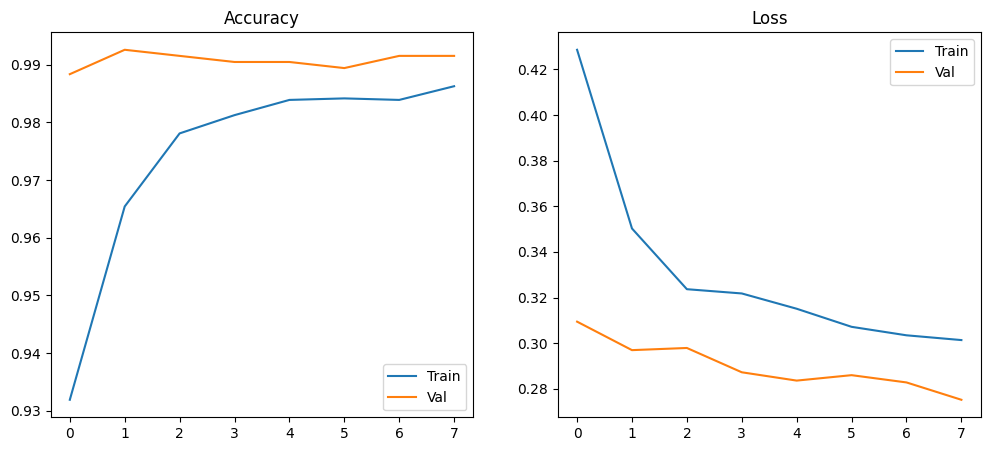

In [9]:
# ============================================
# VISUALIZATION
# ============================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(best_history.history['accuracy'], label='Train')
plt.plot(best_history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(best_history.history['loss'], label='Train')
plt.plot(best_history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()

In [11]:
test_dir  = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/kaggle_test_final"

In [12]:
# ============================================
# SUBMISSION
# ============================================

results = []

for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob = best_model.predict(img_array, verbose=0)[0][0]

    # 🔥 FIXED UNIVERSAL LABEL
    label = idx_to_class[int(prob > 0.5)]

    results.append([img_name, label])

submission = pd.DataFrame(results, columns=["ID", "Label"])
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv ready!")

✅ submission.csv ready!


In [15]:
submission.head()

,ID,Label
0,img_4_684.jpg,chihuahua
1,img_3_835.jpg,muffin
2,img_0_340.jpg,chihuahua
3,img_2_138.jpg,muffin
4,img_3_570.jpg,muffin


CORRECT VERSION (0 / 1 OUTPUT)

Replace ONLY the submission part with this:

# ============================================
# SUBMISSION (0 / 1 FORMAT)
# ============================================

results = []

for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob = best_model.predict(img_array, verbose=0)[0][0]

    # 🔥 OUTPUT AS 0 / 1
    label = int(prob > 0.5)

    results.append([img_name, label])

submission = pd.DataFrame(results, columns=["ID", "Label"])
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv (0/1 format) ready!")

# ============================================
# AUTO SUBMISSION FORMAT (SMART)
# ============================================

# ---- OPTION: Force format manually ----
FORCE_NUMERIC = None   # set True (0/1) or False (text) or None (auto)

# ---- Detect format automatically ----
if FORCE_NUMERIC is None:
    # If class names are numeric strings → use numeric
    if all(c.isdigit() for c in class_names):
        use_numeric = True
    else:
        use_numeric = False
else:
    use_numeric = FORCE_NUMERIC

print("📌 Submission format:", "0/1" if use_numeric else "text labels")

# ---- Create reverse mapping ----
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

results = []

for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob = best_model.predict(img_array, verbose=0)[0][0]
    pred_index = int(prob > 0.5)

    # ---- Smart label output ----
    if use_numeric:
        label = pred_index
    else:
        label = idx_to_class[pred_index]

    results.append([img_name, label])

submission = pd.DataFrame(results, columns=["ID", "Label"])
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv ready!")
submission.head()

🏆 FINAL CLEAN UNIVERSAL CODE (MODULAR + FLEXIBLE)
🔹 CELL 1 — Imports
# ============================================
# IMPORTS
# ============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator, image
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
🔹 CELL 2 — CONFIG (EDIT HERE ONLY)
# ============================================
# CONFIG (CHANGE HERE ONLY)
# ============================================

train_dir = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/train"
test_dir  = "/kaggle/input/competitions/cs-460-muffin-vs-chihuahua-classification-challenge/test"

IMG_SIZE = 192
BATCH_SIZE = 16
EPOCHS = 8

# 🔥 CHANGE MODEL HERE: "mobilenet" / "resnet" / "efficientnet"
MODEL_NAME = "efficientnet"

# 🔥 FORCE OUTPUT FORMAT:
# None = auto detect
# True = force 0/1
# False = force text labels
FORCE_NUMERIC = None
🔹 CELL 3 — Data Pipeline
# ============================================
# DATA PIPELINE
# ============================================

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# 🔥 Class info
class_names = list(train_gen.class_indices.keys())
idx_to_class = {v:k for k,v in train_gen.class_indices.items()}

print("Classes:", class_names)
🔹 CELL 4 — Model Builder (EASY SWITCH)
# ============================================
# MODEL BUILDER (SWITCHABLE)
# ============================================

from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0

def build_model(name):

    # ---- Choose base model ----
    if name == "mobilenet":
        base = MobileNetV2(weights='imagenet', include_top=False,
                           input_shape=(IMG_SIZE, IMG_SIZE, 3))

    elif name == "resnet":
        base = ResNet50(weights='imagenet', include_top=False,
                        input_shape=(IMG_SIZE, IMG_SIZE, 3))

    else:
        base = EfficientNetB0(weights='imagenet', include_top=False,
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))

    base.trainable = False  # freeze

    # ---- Custom head ----
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)

    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    return model
🔹 CELL 5 — Train Model
# ============================================
# TRAINING
# ============================================

model = build_model(MODEL_NAME)

callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(patience=2, factor=0.3)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)
🔹 CELL 6 — Visualization
# ============================================
# VISUALIZATION
# ============================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()
🔹 CELL 7 — AUTO OUTPUT DETECTION
# ============================================
# AUTO OUTPUT FORMAT DETECTION
# ============================================

if FORCE_NUMERIC is None:
    # If class names are numeric → use 0/1
    if all(c.isdigit() for c in class_names):
        use_numeric = True
    else:
        use_numeric = False
else:
    use_numeric = FORCE_NUMERIC

print("Submission format:", "0/1" if use_numeric else "text labels")
🔹 CELL 8 — Submission (FINAL)
# ============================================
# CREATE SUBMISSION
# ============================================

results = []

for img_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prob = model.predict(img_array, verbose=0)[0][0]
    pred_index = int(prob > 0.5)

    # 🔥 AUTO FORMAT
    if use_numeric:
        label = pred_index
    else:
        label = idx_to_class[pred_index]

    results.append([img_name, label])

submission = pd.DataFrame(results, columns=["ID", "Label"])
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv ready!")
submission.head()
🎯 WHY THIS IS BETTER
✔ You can easily switch model:
MODEL_NAME = "mobilenet"
MODEL_NAME = "resnet"
MODEL_NAME = "efficientnet"
✔ Output auto-detect:
muffin/chihuahua → text
0/1 dataset → numeric
or force manually
✔ Clean structure:
Change only CONFIG
Everything else adapts